<a href="https://colab.research.google.com/github/aragaoian/ai-assignments/blob/master/Exercico_4_Ian_C_Aragao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import tensorflow as tf
from tensorflow import keras

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

### Sanitização e Normalização

In [ ]:
white_wine_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
white_df = pd.read_csv(white_wine_url, sep=";")

In [ ]:
white_df.drop_duplicates(inplace=True)
white_df.duplicated().sum()

np.int64(0)

In [ ]:
"""
    Regra
    * classe 0: vinhos com quality <= 6
    * classe 1: vinhos com quality >= 7
"""
white_df["quality"] = np.where(white_df["quality"] <= 6, 0, 1)

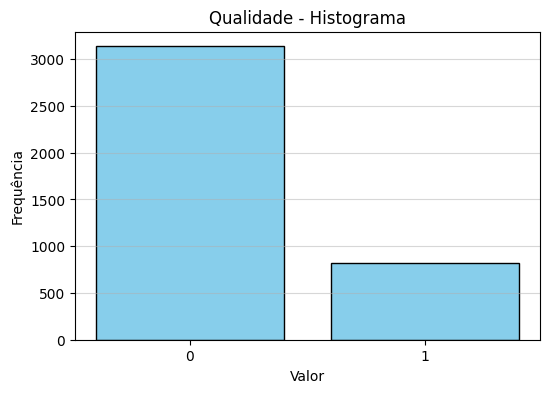

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(
    white_df["quality"],
    bins=[0, 1, 2],
    color='skyblue',
    edgecolor='black',
    rwidth=0.8
)

plt.title('Qualidade - Histograma')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.xticks([0.5, 1.5], ['0', '1'])
plt.grid(axis='y', alpha=0.5)

In [ ]:
print(white_df["quality"].value_counts())

quality
0    3136
1     825
Name: count, dtype: int64


In [ ]:
y = white_df["quality"]
X = white_df.drop(columns=["quality"])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2,
    random_state=42,
    stratify=y
)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Normal

In [ ]:
VERBOSE = False

In [ ]:
_, features = X.shape
NUM_CLASSES = 2

model = keras.models.Sequential([
    keras.layers.InputLayer(shape=(features,), name="input"),
    keras.layers.Dense(4, activation="relu"),
    keras.layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=VERBOSE,
)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 4)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58 (232.00 B)

 Trainable params: 58 (232.00 B)

 Non-trainable params: 0 (0.00 B)

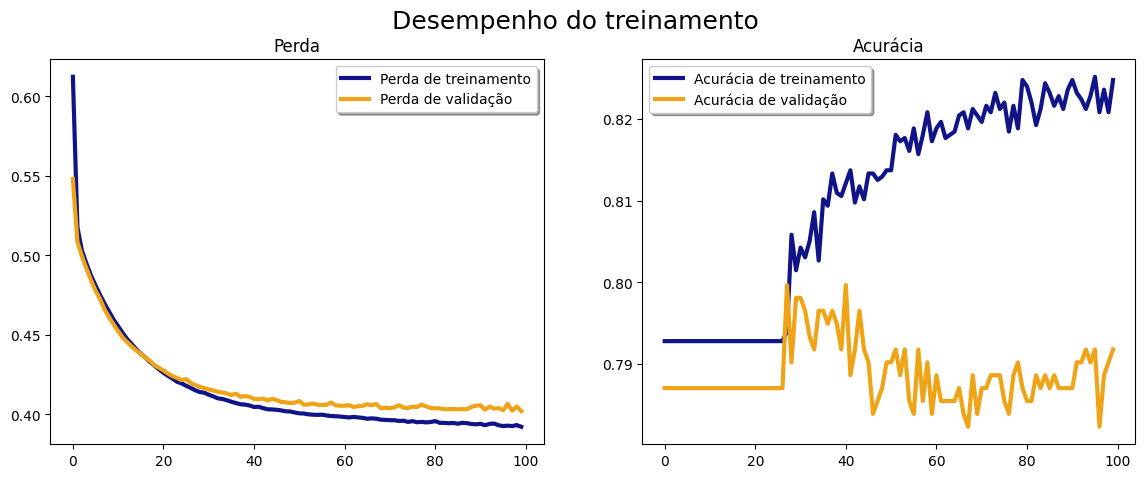

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(history.history['loss'], color='#111487', linewidth=3, label='Perda de treinamento')
ax[0].plot(history.history['val_loss'], color='#EFA316', linewidth=3, label='Perda de validação')
ax[0].legend(loc='best', shadow=True)
ax[0].set_title('Perda')

ax[1].plot(history.history['accuracy'], color='#111487', linewidth=3, label='Acurácia de treinamento')
ax[1].plot(history.history['val_accuracy'], color='#EFA316', linewidth=3, label='Acurácia de validação')
ax[1].legend(loc='best', shadow=True)
ax[1].set_title('Acurácia')

plt.suptitle('Desempenho do treinamento', fontsize=18)
plt.show()

### Com Class Weight

1. O uso de class_weight alterou o desempenho? <br>
R: Sim. O aumento da loss de treinamento ocorre devido à penalização diferenciada das classes, e não necessariamente indica pior generalização.

2. Houve impacto na acurácia geral? <br>
R: Sim também. Mas não foi de forma tão significativa, a queda provavelmente se da pelo fato de que adicionando o class weight, o modelo tende a penalizar mais erros na classe minoritária, o que acaba deixando o modelo mais "justo" ou com menos viés.

3. Houve impacto no desempenho da classe minoritária? <br>
R: Possivelmente. É um pouco complicado dizer se o class weights impacta diretamente na classe minoritária sem olhar para outras métricas como Precision/Recall ou F1-Score. Dessa forma, observando o gráfico com diferenças entre treinamento e validação tanto em acurácia, mas principalmente em loss, há indícios que, neste caso, o class weights impactou no desempenho da classe minoritária.

Refs:
https://andersource.dev/2025/05/05/imbalanced-learning.html

In [ ]:
_, features = X.shape
NUM_CLASSES = 2

model = keras.models.Sequential([
    keras.layers.InputLayer(shape=(features,), name="input"),
    keras.layers.Dense(4, activation="relu"),
    keras.layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

class_weight = {
    0: 1.0,
    1: 2.5
}

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=VERBOSE,
    class_weight=class_weight
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 4)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58 (232.00 B)

 Trainable params: 58 (232.00 B)

 Non-trainable params: 0 (0.00 B)

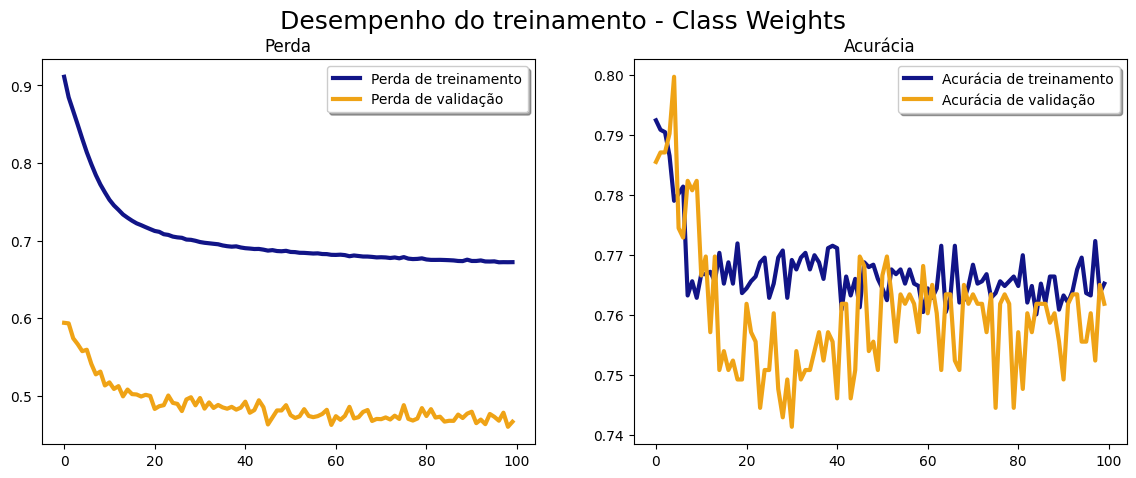

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(history.history['loss'], color='#111487', linewidth=3, label='Perda de treinamento')
ax[0].plot(history.history['val_loss'], color='#EFA316', linewidth=3, label='Perda de validação')
ax[0].legend(loc='best', shadow=True)
ax[0].set_title('Perda')

ax[1].plot(history.history['accuracy'], color='#111487', linewidth=3, label='Acurácia de treinamento')
ax[1].plot(history.history['val_accuracy'], color='#EFA316', linewidth=3, label='Acurácia de validação')
ax[1].legend(loc='best', shadow=True)
ax[1].set_title('Acurácia')

plt.suptitle('Desempenho do treinamento - Class Weights ', fontsize=18)
plt.show()

### Com Early Stopping

1. Em que situação o uso de EarlyStopping se justifica? <br>
R: O método de regularização é principalmente utilizado para evitar o overfitting, parando o treinamento quando a performance do modelo começa a decair. Em redes maiores e mais complexas, a abordagem assiste na redução dos custos computacionais e também na necessidade de mexer manualmente nos híper-parâmetros do modelo.

2. As curvas sugerem overfitting? <br>
R: Não. Pela simplicidade do modelo, baixo volume de dados, loss alto e um acurácia não muito convincente, pode-se até sugir um underfitting.

3. O uso de EarlyStopping melhorou a generalização do modelo? <br>
R: O método não trouxe ganhos significativos de generalização, pois o modelo já não apresentava sinais claros de overfitting. Seu principal benefício foi evitar treinamento desnecessário. Além disso, melhorias mais expressivas na generalização tendem a vir de fatores como melhor ajuste de hiperparâmetros, maior volume ou qualidade dos dados, enquanto o EarlyStopping atua principalmente como uma técnica de regularização.

Refs: <br>
https://machinelearningmastery.com/early-stopping-to-avoid-overtraining-neural-network-models/ <br>

https://www.dremio.com/wiki/early-stopping/

In [ ]:
_, features = X.shape
NUM_CLASSES = 2

model = keras.models.Sequential([
    keras.layers.InputLayer(shape=(features,), name="input"),
    keras.layers.Dense(4, activation="relu"),
    keras.layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping_callback],
    verbose=VERBOSE,
)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 4)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 2)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58 (232.00 B)

 Trainable params: 58 (232.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 76: early stopping
Restoring model weights from the end of the best epoch: 73.


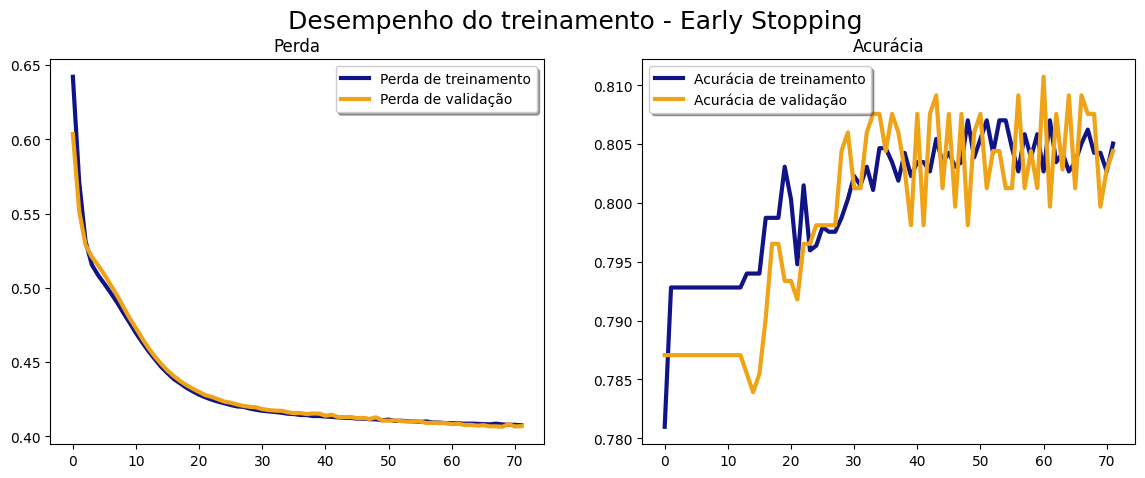

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(history.history['loss'], color='#111487', linewidth=3, label='Perda de treinamento')
ax[0].plot(history.history['val_loss'], color='#EFA316', linewidth=3, label='Perda de validação')
ax[0].legend(loc='best', shadow=True)
ax[0].set_title('Perda')

ax[1].plot(history.history['accuracy'], color='#111487', linewidth=3, label='Acurácia de treinamento')
ax[1].plot(history.history['val_accuracy'], color='#EFA316', linewidth=3, label='Acurácia de validação')
ax[1].legend(loc='best', shadow=True)
ax[1].set_title('Acurácia')

plt.suptitle('Desempenho do treinamento - Early Stopping', fontsize=18)
plt.show()